## 1. Load Data ##

In [7]:
import ast
import pandas as pd

df = pd.read_csv(
    "../data/processed/cleaned_jobs.csv"
)

df["skills"] = (
    df["skills"]
    .apply(ast.literal_eval)
)

from pathlib import Path

Path("../outputs/figures").mkdir(
    parents=True,
    exist_ok=True
)

## 2. Explode Skills ##

In [8]:
exploded = (
    df
    .explode("skills")
)

## 3. Average Salary by Skills ##

In [9]:
salary_skill = (
    exploded
    .groupby("skills")
    ["salary_numeric"]
    .mean()
    .sort_values(
        ascending=False
    )
)

## 4. Top Paying Skills ##

In [10]:
salary_skill.head(20)

skills
scala               157815.282353
hadoop              145732.313433
spark               145026.267081
r                   142065.943149
amazon              140226.549020
sql                 131277.998869
azure               128633.867742
python              128218.301562
bash                127471.600000
tableau             127467.456897
gcp                 127326.452830
database            126868.536145
aws                 125163.116972
machine learning    122509.550862
tensorflow          121355.863636
linux               118811.413043
deep learning       118126.862360
java                116129.253425
pytorch             113317.621622
scikit-learn        112981.467033
Name: salary_numeric, dtype: float64

## 5. Visualization ##

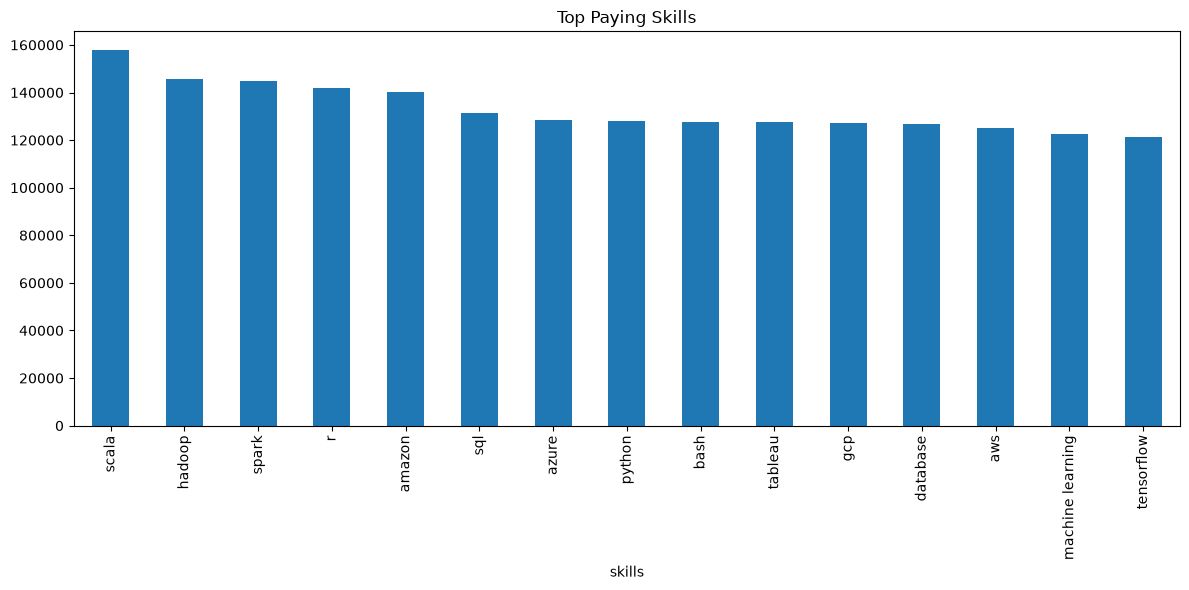

In [12]:
import matplotlib.pyplot as plt

top_salary_skills = (
    salary_skill
    .head(15)
)

plt.figure(figsize=(12,6))

top_salary_skills.plot(
    kind="bar"
)

plt.title("Top Paying Skills")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/top_paying_skills.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Salary by Seniority ##

In [13]:
(
    df.groupby(
        "seniority_level"
    )
    ["salary_numeric"]
    .mean()
)

seniority_level
Unknown     133824.800000
junior       87939.740000
lead        150339.099138
midlevel    100323.601770
senior      135549.150000
Name: salary_numeric, dtype: float64

## 7. Visualization ##

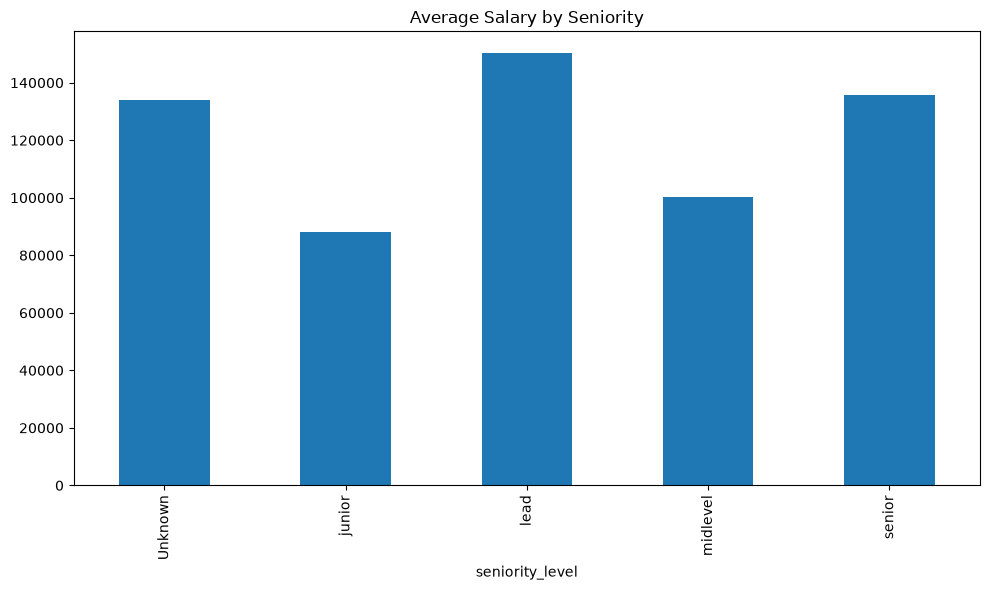

In [14]:
import matplotlib.pyplot as plt

salary_seniority = (
    df.groupby("seniority_level")
    ["salary_numeric"]
    .mean()
)

plt.figure(figsize=(10,6))

salary_seniority.plot(
    kind="bar"
)

plt.title("Average Salary by Seniority")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/salary_by_seniority.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()